# 数据清洗流水线作业 - Polars Lazy API

使用 Polars 流式处理（Lazy API）完成数据清洗与脱敏，并将结果持久化为 Parquet 格式。

## 清洗与脱敏要求
1. **脱敏**：使用 SHA256 哈希算法对 user_id 进行隐私脱敏
2. **剔除**：过滤掉 event_id 为空的异常脏数据行
3. **修复**：将 event_type 中的拼写错误进行标准化替换
4. **性能验证**：记录并输出总运行时长
5. **感知对比**：对比 Parquet 与原 CSV 的文件体积

In [1]:
import polars as pl
import hashlib
import time
import os

In [2]:
# ==================== 配置 ====================
INPUT_FILE = "large_data.csv"
OUTPUT_FILE = "clean_data.parquet"

# 拼写错误映射表
TYPO_CORRECTIONS = {
    "clik": "click",
    "clic": "click",
    "cllick": "click",
    "ckick": "click",
    "purchse": "purchase",
    "purhcase": "purchase",
    "puchase": "purchase",
    "serch": "search",
    "seach": "search",
    "serach": "search",
    "vew": "view",
    "vieew": "view",
    "viwe": "view",
    "logut": "logout",
    "log-out": "logout",
    "logot": "logout",
    "logn": "login",
    "loign": "login",
    "LogIn": "login",
    "login ": "login",  # 带空格
}

# ==================== 哈希脱敏函数 ====================
def hash_user_id(user_id: str) -> str:
    """使用 SHA256 对用户 ID 进行哈希脱敏"""
    if user_id is None:
        return hashlib.sha256(b"null").hexdigest()
    return hashlib.sha256(str(user_id).encode('utf-8')).hexdigest()

print("配置加载完成")

配置加载完成


In [3]:
# ==================== 获取原始文件信息 ====================
original_size = os.path.getsize(INPUT_FILE)
print(f"原始文件：{INPUT_FILE}")
print(f"原始大小：{original_size / (1024*1024):.2f} MB")

原始文件：large_data.csv
原始大小：257.56 MB


In [4]:
# ==================== 开始计时 ====================
start_time = time.time()
print(f"开始数据清洗流水线...")
print(f"启动时间：{time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start_time))}")

开始数据清洗流水线...
启动时间：2026-03-17 10:54:25


In [5]:
# ==================== Polars Lazy API 流式处理 ====================

# 步骤 1: 懒加载 CSV (不立即读取到内存)
print("[1] 懒加载 CSV 文件...")
q = pl.scan_csv(INPUT_FILE)

# 步骤 2: 过滤 event_id 为空的行
print("[2] 过滤 event_id 为空的异常数据...")
q = q.filter(pl.col("event_id").is_not_null() & (pl.col("event_id") != ""))

# 步骤 3: 修复 event_type 拼写错误
print("[3] 修复 event_type 拼写错误...")
replace_expr = pl.col("event_type")
for typo, correct in TYPO_CORRECTIONS.items():
    replace_expr = replace_expr.replace(typo, correct)

q = q.with_columns([replace_expr.alias("event_type")])

# 步骤 4: 收集数据
print("[4] 执行 Lazy 计划并收集数据...")
df = q.collect()

# 步骤 5: 使用 SHA256 进行脱敏
print("[5] 应用 SHA256 哈希生成 masked_user_id...")
df = df.with_columns([
    pl.col("user_id").cast(pl.Utf8).map_elements(hash_user_id, return_dtype=pl.Utf8).alias("masked_user_id")
])

# 步骤 6: 丢弃原始 user_id 列
print("[6] 丢弃原始 user_id 明文列...")
df = df.drop(["user_id"])

# 重新排列列顺序
cols = ["masked_user_id"] + [c for c in df.columns if c != "masked_user_id"]
df = df.select(cols)

# 步骤 7: 写入 Parquet 文件
print(f"[7] 写入 Parquet 文件：{OUTPUT_FILE}...")
df.write_parquet(OUTPUT_FILE, compression="snappy")

print("数据处理完成!")

[1] 懒加载 CSV 文件...
[2] 过滤 event_id 为空的异常数据...
[3] 修复 event_type 拼写错误...
[4] 执行 Lazy 计划并收集数据...
[5] 应用 SHA256 哈希生成 masked_user_id...


[6] 丢弃原始 user_id 明文列...
[7] 写入 Parquet 文件：clean_data.parquet...
数据处理完成!


In [6]:
# ==================== 结束计时 ====================
end_time = time.time()
total_time = end_time - start_time

print(f"流水线完成时间：{time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(end_time))}")
print(f"总运行时长：{total_time:.2f} 秒 ({total_time/60:.2f} 分钟)")

流水线完成时间：2026-03-17 10:54:26
总运行时长：1.26 秒 (0.02 分钟)


In [7]:
# ==================== 文件体积对比 ====================
output_size = os.path.getsize(OUTPUT_FILE)
compression_ratio = original_size / output_size if output_size > 0 else 0
space_saved = (original_size - output_size) / (1024*1024)

print("\n" + "=" * 60)
print("文件体积对比")
print("=" * 60)
print(f"原始文件 (CSV):     {original_size / (1024*1024):.2f} MB")
print(f"输出文件 (Parquet): {output_size / (1024*1024):.2f} MB")
print(f"压缩比：            {compression_ratio:.2f}x")
print(f"节省空间：          {space_saved:.2f} MB ({(1 - output_size/original_size)*100:.1f}%)")


文件体积对比
原始文件 (CSV):     257.56 MB
输出文件 (Parquet): 135.40 MB
压缩比：            1.90x
节省空间：          122.16 MB (47.4%)


In [8]:
# ==================== 清洗结果统计 ====================
original_rows = pl.scan_csv(INPUT_FILE).select(pl.len()).collect().item()

print("\n" + "=" * 60)
print("清洗结果统计")
print("=" * 60)
print(f"原始记录数：{original_rows:,}")
print(f"清洗后记录数：{len(df):,}")
print(f"过滤掉的记录数：{original_rows - len(df):,}")


清洗结果统计
原始记录数：1,000,000
清洗后记录数：997,115
过滤掉的记录数：2,885


In [9]:
# ==================== 脱敏验证 ====================
print("\n脱敏验证:")
print(f"  masked_user_id 唯一值数量：{df['masked_user_id'].n_unique():,}")
print(f"  样本 masked_user_id:")
for sample in df['masked_user_id'].head(3).to_list():
    print(f"    {sample}")


脱敏验证:
  masked_user_id 唯一值数量：485,999
  样本 masked_user_id:
    242cf49dc2c16b3dd49056496a85b2b620a0a240c08a0ea80650e3a88d6b7180
    5ff19ab14ece4c88034166f533e7139ab02754def7ff5fe64166f84b5160f9c8
    783a8f23d32db51809c26fde21a482801f6e4d0e74d9d29d06bb36650d488d97


In [10]:
# ==================== 拼写修复验证 ====================
print("\n拼写修复验证 (event_type 分布):")
event_type_dist = df['event_type'].value_counts().sort('count', descending=True)
for row in event_type_dist.iter_rows():
    print(f"  {row[0]}: {row[1]:,} ({row[1]/len(df)*100:.2f}%)")


拼写修复验证 (event_type 分布):
  search: 166,543 (16.70%)
  login: 166,462 (16.69%)
  logout: 166,336 (16.68%)
  click: 166,113 (16.66%)
  purchase: 165,901 (16.64%)
  view: 165,760 (16.62%)


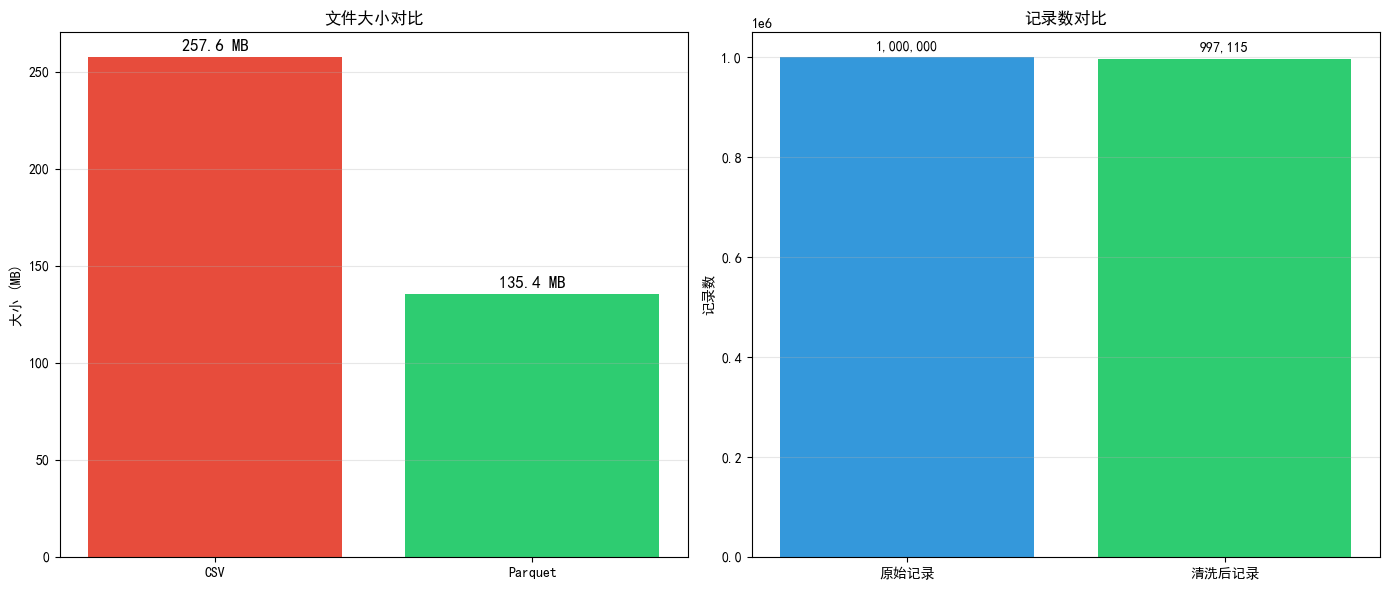


图表已保存为 pipeline_comparison.png


In [11]:
# ==================== 可视化对比 ====================
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 图 1：文件大小对比
file_sizes = [original_size / (1024*1024), output_size / (1024*1024)]
file_labels = [f'CSV\n{file_sizes[0]:.2f} MB', f'Parquet\n{file_sizes[1]:.2f} MB']
colors = ['#e74c3c', '#2ecc71']

bars = axes[0].bar(['CSV', 'Parquet'], file_sizes, color=colors)
axes[0].set_title('文件大小对比')
axes[0].set_ylabel('大小 (MB)')
axes[0].grid(axis='y', alpha=0.3)

# 在柱状图上添加数值标签
for bar, size in zip(bars, file_sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                f'{size:.1f} MB', ha='center', va='bottom', fontsize=12)

# 图 2：记录数对比
row_counts = [original_rows, len(df)]
row_labels = [f'原始\n{original_rows:,}', f'清洗后\n{len(df):,}']

bars = axes[1].bar(['原始记录', '清洗后记录'], row_counts, color=['#3498db', '#2ecc71'])
axes[1].set_title('记录数对比')
axes[1].set_ylabel('记录数')
axes[1].grid(axis='y', alpha=0.3)

# 在柱状图上添加数值标签
for bar, count in zip(bars, row_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000, 
                f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('pipeline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n图表已保存为 pipeline_comparison.png")